In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt','r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [8]:
#Dataset Building
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdv, Ydv = build_dataset(words[n1:n2])
Xts, Yts = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [11]:
dim = 10
block_size = 3

In [18]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,dim), generator = g)
W1 = torch.randn((dim*block_size, 300), generator = g)
b1 = torch.randn(W1.shape[1], generator = g)
W2 = torch.randn((W1.shape[1],27), generator = g)
b2 = torch.randn(27, generator = g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True
sum(p.nelement() for p in parameters)

17697

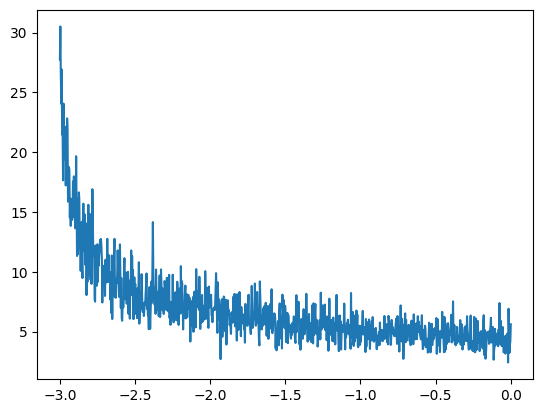

In [25]:
#learning rate tuning
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

lri = []
lossi = []
for i in range(1000):

    ix = torch.randint(0, Xdv.shape[0], (32,))
    
    emb = C[Xdv[ix]]
    h = torch.tanh(emb.view(-1,dim*block_size) @ W1 + b1) # (32,300)
    logits = h @ W2 + b2 # (32,27)
    # counts = logits.exp()
    # probs = counts / counts.sum(1, keepdims=True)
    # loss = -probs[torch.arange(32), Ydv].log().mean()
    loss = F.cross_entropy(logits,Ydv[ix])
    
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lrs[i]
    for p in parameters:
        p.data += -0.1 * p.grad

    lri.append(lre[i])
    lossi.append(loss.item())

plt.plot(lri,lossi)

In [42]:
minloss = 1000

In [62]:
#gradient descent
for _ in range(50000):

    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,dim*block_size) @ W1 + b1) # (32,300)
    logits = h @ W2 + b2 # (32,27)
    # counts = logits.exp()
    # probs = counts / counts.sum(1, keepdims=True)
    # loss = -probs[torch.arange(32), Ytr].log().mean()
    loss = F.cross_entropy(logits,Ytr[ix])
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    for p in parameters:
        p.data += -(0.01) * p.grad

print(loss.item())

2.1323812007904053


In [63]:
#loss on devset
emb = C[Xdv]
h = torch.tanh(emb.view(-1,dim*block_size) @ W1 + b1) # (32,300)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits,Ydv)
print(loss.item())
if loss.item() < minloss:
    model = parameters
    minloss = loss.item()

2.1086864471435547


In [64]:
minloss

2.1068711280822754

In [65]:
model

[tensor([[ 0.6856, -0.3173,  0.0481, -0.2363,  0.2277,  0.1439, -0.5585,  0.5097,
           0.1725,  0.1678],
         [-0.6628,  0.4433, -0.1656,  0.1617,  1.6107,  3.5123,  1.5400, -1.9520,
           1.7272, -0.5729],
         [ 1.0179,  1.0292, -2.3206,  1.4259,  0.2613,  0.7946,  0.6210,  0.4905,
          -1.1312, -0.1311],
         [-0.8543,  1.9654, -0.9093,  0.8270, -0.4775,  0.4010, -1.1149,  0.7396,
          -0.4350,  0.7116],
         [-0.6504,  0.9030, -0.7189, -0.0387, -1.1003,  1.4893,  1.1242,  1.6787,
          -0.8386, -0.4977],
         [ 0.2962,  1.3509,  0.3131, -1.5181,  0.4127, -0.3344,  1.0601, -0.8620,
          -0.8440, -0.5419],
         [-1.9149,  0.2040, -1.3759, -0.1183,  1.4110, -0.6934,  2.0224,  1.7879,
          -1.4563,  1.4968],
         [ 0.1060,  1.2684, -1.4962,  1.4849,  0.2796,  2.1249, -0.1446,  0.1125,
          -0.6633, -1.0308],
         [-0.8114, -0.3263, -0.5251, -0.5435, -0.1161, -0.2501,  0.6468, -0.3325,
           0.1180,  0.2142],
 

In [66]:
#loss on testset
emb = C[Xts]
h = torch.tanh(emb.view(-1,dim*block_size) @ W1 + b1) # (32,300)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits,Yts)
print(loss.item())
if loss.item() < minloss:
    model = parameters
    minloss = loss.item()

2.1154277324676514


In [68]:
#sampling from our model

g = torch.Generator().manual_seed(2147483647)

for _ in range(20): 
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples = 1, generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

dex.
maleah.
makilah.
tyheem.
jimitta.
noluwak.
katar.
samiyah.
javer.
gotzi.
moriellah.
jacobert.
kaley.
maside.
eniavion.
rosbuthi.
cameevon.
lucu.
dedri.
antol.
